In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine

Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=17985 sha256=acf425982ad5d5827cd8f819679aabfd19778a5923e00520b9fc7dee91c7a13e
  Stored in directory: /tmp/pip-ephem-wheel-cache-fc_rr7vs/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Using cached plotnine-0.14.5-py3-none-any.whl.metadata (9.3 kB)
  Using cached mizani-0.13.1-py3-none-any.whl.metadata (4.7 kB)
Using cached plotnine-0.14.5-py3-none-any.whl (1.3 MB)
Using cached mizani-0.13.1-py3-none-any.whl (127 kB)


In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine
import xarray as xr

#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine
import seaborn as sns

from scipy import stats
from patsy import ModelDesc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

import math

In [3]:
import fwiVis.fwiVis as fv

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_only/April_1_unmerged_fires_with_FWI.csv"
#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Final_dataset_as_of_20240209.csv"
#fire3 = fv.prep_fire_files(path)

path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
#path = os.path.abspath("data/Quebec_v3_full_data_perimetersMAX_fwi_with_ISI_and_BUIful_timeseries_202534.csv")
fire3 = fv.prep_fire_files(path)
fire_first = fire3

In [4]:
fire3 = fire3.sort_values(by = ["fireID", "t"])

fire3 = fire3[~fire3.FWI.isna()]
# df = fire3[fire3.fireID == '2367']
# df

In [5]:
def corrected_farea_diff(df, var = "farea"):
    #sub_df = df[]
    df = df.drop_duplicates()
    df[f"{var}_diff"] = df[var].diff()
    min_t = df.t.min()
    #print()
    #print(df.loc[df.t == min_t, ["fireID", "t", "farea", "farea_diff"]])
    
    if(np.isnan(*df.loc[df.t == min_t, [f"{var}_diff"]].values)):
        df.loc[df.t == min_t, [f"{var}_diff"]] = df.loc[df.t == min_t, [f"{var}"]].values
    else:
        print("Error! First value not NaN")
        df = None
    return(df)

In [6]:
def just_the_igs(df,): ## Reminder that this will only acocunt for the earliest ignition from a multi-fire complex. 

    df["is_ig"] = False
    df.loc[df.t == df.t.min(), ['is_ig']] = True
    
    return(df)

def extinction(df, days_past = 1):
    df.loc[:, ['is_ext']] = False
    df.loc[:, ["t"]] = df.t.astype("datetime64[ns]")
    final_t = df[df.n_newpixels > 0].t.astype("datetime64[ns]").max()
    post_fire = final_t + timedelta(days = days_past)

    if (pd.isnull(np.datetime64(str(final_t)))):
        df.loc[(df.t == df.t.min()), ['is_ext']] = True
    else:
        df.loc[(df.t  > final_t)  & (df.t  <= post_fire), ['is_ext']] = True
    #print(final_t)
    #print(df.fireID.unique())
    #print(len(df[df["is_ext"] == True]))
    return(df)


#fire3 = fire3[~fire3.FWI.isna()]

In [7]:
def chop_fires_at_end(df):
    final_t = df[df.n_newpixels > 0].t.max()
    df = df[df.t <= final_t]
    return(df)

#post_fr = fire3.groupby("fireID").apply(extinction).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)


fire3 = fire3.sort_values(by = ["fireID", "t"])

/tmp/ipykernel_547/3123191034.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [8]:
### make a plot of the distribution of forwar-facing relative fire area growth
fire3 = fire3.drop_duplicates()
fire3["farea_diff_stand"] = fire3.groupby("fireID").farea.diff()

fire3["corrected_flinelen"] = fire3.flinelen + 0.001

## Fireline 
fire3["frac_change"] = fire3.groupby("fireID").farea.pct_change()
fire3["flinelen_frac_change"] = fire3.groupby("fireID").corrected_flinelen.pct_change()

fire3["fperim_shifted"] = fire3.groupby("fireID").fperim.shift(periods = 1)
fire3["flinelen_diff"] = fire3.groupby("fireID").flinelen.diff()
fire3["fperim_diff"] = fire3.groupby("fireID").fperim.diff()


fire3["farea_shifted"] = fire3.groupby("fireID").farea.shift(periods = 1)
fire3["meanFRP_shifted"] = fire3.groupby("fireID").meanFRP.shift(periods = 1)
fire3["flinelen_shifted"] = fire3.groupby("fireID").flinelen.shift(periods = 1)
fire3["n_newpixels_shifted"] = fire3.groupby("fireID").n_newpixels.shift(periods = 1)
fire3["GEOS5_IMERGEARLY_shifted"] = fire3.groupby("fireID")['GEOS-5.IMERGEARLY'].shift(periods = 1)
fire3["FWI_shifted"] = fire3.groupby("fireID")['FWI'].shift(periods = 1)
fire3["FWI_lead_1_shifted"] = fire3.groupby("fireID")['FWI_lead_1'].shift(periods = 1)
fire3["FWI_forecast_average"] = (fire3.FWI + fire3.FWI_lead_1)/2
fire3["FWI_forecast_average_shifted"] = (fire3.FWI_shifted + fire3.FWI_lead_1_shifted)/2
# fire3["ISI_shifted"] = fire3.groupby("fireID")['ISI'].shift(periods = 1)
# fire3["ISI_lead_1_shifted"] = fire3.groupby("fireID")['ISI_lead_1'].shift(periods = 1)
# fire3["ISI_forecast_average"] = (fire3.ISI + fire3.ISI_lead_1)/2
# fire3["ISI_forecast_average_shifted"] = (fire3.ISI_shifted + fire3.ISI_lead_1_shifted)/2
# fire3["BUI_shifted"] = fire3.groupby("fireID")['BUI'].shift(periods = 1)
# fire3["BUI_lead_1_shifted"] = fire3.groupby("fireID")['BUI_lead_1'].shift(periods = 1)
# fire3["BUI_forecast_average"] = (fire3.BUI + fire3.BUI_lead_1)/2
# fire3["BUI_forecast_average_shifted"] = (fire3.BUI_shifted + fire3.BUI_lead_1_shifted)/2




fire3["corrected_shifted_flinelen"] = fire3.flinelen_shifted + 0.001
fire3["flinelen_shifted_frac_change"] = fire3.groupby("fireID").corrected_shifted_flinelen.pct_change()

fire3["farea_shifted_exp"] = fire3["farea_shifted"] ** (1/10)
fire3["meanFRP_shifted_exp"] = fire3["meanFRP_shifted"]** (1/10)
fire3["flinelen_shifted_exp"] = fire3["flinelen_shifted"]** (1/10)
fire3["n_newpixels_shifted_exp"] = fire3["n_newpixels_shifted"]** (1/10)


fire3["spread_bool"] = fire3.frac_change > 0
fire3["spread_bool"] = fire3["spread_bool"].astype("int")


fire3["spread_bool_50"] = fire3.frac_change > 0.5
fire3["spread_bool_50"] = fire3["spread_bool_50"].astype("int")

fire3["spread_bool_frac_01"] = fire3.frac_change > 0.1
fire3["spread_bool_frac_01"] = fire3["spread_bool_frac_01"].astype("int")

fire3["spread_bool_frac_05"] = fire3.frac_change > 0.05
fire3["spread_bool_frac_05"] = fire3["spread_bool_frac_05"].astype("int")

fire3["spread_bool_frac_025"] = fire3.frac_change > 0.025
fire3["spread_bool_frac_025"] = fire3["spread_bool_frac_025"].astype("int")



fire3["spread_bool_100"] = fire3.frac_change > 1
fire3["spread_bool_100"] = fire3["spread_bool_100"].astype("int")

fire3.loc[:, "spread_bool_200"] = fire3.farea_diff_stand > 2
fire3.loc[:, "spread_bool_200"] = fire3["spread_bool_200"].astype("float")

fire3.loc[:, "spread_bool_400"] = fire3.farea_diff_stand > 4
fire3.loc[:, "spread_bool_400"] = fire3["spread_bool_400"].astype("float")

fire3.loc[:, "spread_bool_600"] = fire3.farea_diff_stand > 6
fire3.loc[:, "spread_bool_600"] = fire3["spread_bool_600"].astype("float")

fire3.loc[:, "GEOS5_IMERGEARLY"] = fire3['GEOS-5.IMERGEARLY']

fire3.loc[:, "n_newpixels_bool"] = fire3.n_newpixels > 0
fire3.loc[:,  "n_newpixels_bool"] = fire3[ "n_newpixels_bool"].astype("int")

fire3.loc[:, "GEOS_ave"] = (fire3['GEOS5_IMERGEARLY'] + fire3['GEOS5_IMERGEARLY_shifted'])/ 2





def relative_growth(df):
    df["relative_growth"] =  (df.farea_diff + df.farea_shifted_back) / df.farea_shifted_back
    return(df)

def just_the_igs(df,): ## Reminder that this will only acocunt for the earliest ignition from a multi-fire complex. 

    df_fr = df[~(df.geometry.isna())]
    t_min = df_fr.t.min()
    df["is_ig"] = False
    df.loc[(df.t == t_min), ['is_ig']] = True
    
    return(df)

def extinction(df, days_past = 1):
    df.loc[:, ['is_ext']] = False
    df.loc[:, ["t"]] = df.t.astype("datetime64[ns]")
    final_t = df[df.n_newpixels > 0].t.astype("datetime64[ns]").max()
    post_fire = final_t + timedelta(days = days_past)

    if (pd.isnull(np.datetime64(str(final_t)))):
        df.loc[(df.t == df.t.min()), ['is_ext']] = True
    else:
        df.loc[(df.t  > final_t)  & (df.t  <= post_fire), ['is_ext']] = True
    #print(final_t)
    #print(df.fireID.unique())
    #print(len(df[df["is_ext"] == True]))
    return(df)



fire3 = fire3.groupby("fireID").apply(extinction).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(just_the_igs).reset_index(drop = True)

/tmp/ipykernel_547/1917819873.py:38: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
/tmp/ipykernel_547/1917819873.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 1. 0. ... 0. 0. 0.]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
/tmp/ipykernel_547/1917819873.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 1. 0. ... 0. 0. 0.]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
/tmp/ipykernel_547/1917819873.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 1. 0. ... 0. 0. 0.]'

# Make Sampling Scheme

In [9]:
def get_num_days(fire3):
    t_min = fire3.t.min()
    fire3.loc[:, "days_since_ignition"] = fire3.t.astype("datetime64[ns]") - t_min
    return(fire3)

fire3 = fire3.groupby("fireID").apply(get_num_days).reset_index(drop = True)



# Get lat fof smapling scheme 
def get_final_centroid(fire3):
    if(fire3.crs != 4326):
        print("This is is a different projection from 4326!")
        return(None)
    #print(fire3.crs)
    fire3[fire3.farea == fire3.farea.max()].geometry.centroid.y
    fire3.loc[:, "Lat"] = fire3[fire3.farea == fire3.farea.max()].geometry.iloc[0].centroid.y
    fire3.loc[:, "Lon"] = fire3[fire3.farea == fire3.farea.max()].geometry.iloc[0].centroid.x
    return(fire3)

fire_projected = fire3.to_crs(4326)
fire_projected = fire_projected.groupby("fireID").apply(get_final_centroid).reset_index(drop = True)


def make_two_dfs(fire3, by = "farea"):
    '''
    Makes two dataframes with roughly the same proportion of fires of different sizes
    '''
    max_area = fire3.groupby("fireID")[by].max()
    max_area = pd.DataFrame({"fireID": max_area.index, 
                            f"{by}_max" : max_area.values})
    
    
    max_area = max_area.sort_values(by = f"{by}_max")
    fit_ids = max_area.iloc[::2].fireID
    test_ids = max_area.iloc[1::2].fireID
    
    
    
    fire = fire3[fire3.fireID.isin(fit_ids)]
    fire_test = fire3[fire3.fireID.isin(test_ids)]
    return(fire, fire_test)

def make_two_dfs_sub(fire3, by = "farea", sub = 0):
    '''
    Makes two dataframes with roughly the same proportion of fires of different sizes
    '''
    max_area = fire3.groupby("fireID")[by].max()
    max_area = pd.DataFrame({"fireID": max_area.index, 
                            f"{by}_max" : max_area.values})
    
    
    max_area = max_area.sort_values(by = f"{by}_max", ascending = False)
    #return(max_area)

    if(sub != 0):
        if(sub > 0):
            start = round(sub * len(max_area))
            end = len(max_area)
        if(sub < 0):
            start = round(len(max_area) - (sub * len(max_area)))
            end = len(max_area)
        #print(start)
        #print(end)
        max_area = max_area[start:end].reset_index()
        
    fit_ids = max_area.iloc[::2].fireID
    test_ids = max_area.iloc[1::2].fireID
    
    
    
    fire = fire3[fire3.fireID.isin(fit_ids)]
    fire_test = fire3[fire3.fireID.isin(test_ids)]
    return(fire, fire_test)

fire, fire_test = make_two_dfs(fire3)


fire_lat, fire_test_lat = make_two_dfs(fire_projected, by = "Lat")

fire_sub, fire_test_sub = make_two_dfs_sub(fire3, by = "farea", sub = 0.10)

fire_early = fire[fire.days_since_ignition.dt.days.astype("int") <= 7]
fire_test_early = fire_test[fire_test.days_since_ignition.dt.days.astype("int") <= 7]

/tmp/ipykernel_547/1056426783.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_547/1056426783.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/tmp/ipykernel_547/1056426783.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/tmp/ipykernel_547/1056426783.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to

In [10]:
def calc_confusion_matrix(fire_delta, fire_test, thresh, x, y, pred_column):
    fire_delta = fire_delta.dropna()
    will_grow = fire_delta[fire_delta[pred_column] > thresh][x].min()
    if(will_grow == 0):
        print("No growth detected")
    if(len(fire_delta[(fire_delta[x] >= will_grow)]) == 0):
        print(f"No growth detected, no values over {will_grow} in {x}")
    #will_grow_lower = fire_delta[fire_delta.conf_int_low > thresh][x].min()
    #will_grow_upper = fire_delta[fire_delta.conf_int_high > thresh][x].min()
    
    
    false_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y]) ## said it would grow, but didn't
    false_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y])
    true_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y])
    
    #print(f"For in-sampl false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}")
    if(fire_test is None):
        return([false_positives, false_negatives, true_positives, true_negatives])


    # #### Out of sample confusion matrix
    
    false_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y]) ## said it would grow, but didn't
    false_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y])
    true_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y])
    
    #print(f"For out of sample --- false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}. Sum = ({false_positives + true_positives + false_negatives + true_negatives})")
    return([false_positives, false_negatives, true_positives, true_negatives])

def calc_confusion_matrix_individual(fire_delta, fire_test, thresh, x, y, pred_column):
    fire_delta = fire_delta.dropna()
    will_grow = fire_delta[fire_delta[pred_column] > thresh][x].min()
    if(will_grow == 0):
        print("No growth detected")
    if(len(fire_delta[(fire_delta[x] >= will_grow)]) == 0):
        print(f"No growth detected, no values over {will_grow} in {x}")
        return(None)
    #will_grow_lower = fire_delta[fire_delta.conf_int_low > thresh][x].min()
    #will_grow_upper = fire_delta[fire_delta.conf_int_high > thresh][x].min()
    
    
    false_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y]) ## said it would grow, but didn't
    false_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y])
    true_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y])
    
    #print(f"For in-sampl false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}")
    if(fire_test is None):
        return([false_positives, false_negatives, true_positives, true_negatives])


    # #### Out of sample confusion matrix
    
    false_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y]) ## said it would grow, but didn't
    false_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y])
    true_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y])
    
    #print(f"For out of sample --- false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}. Sum = ({false_positives + true_positives + false_negatives + true_negatives})")
    return([false_positives, false_negatives, true_positives, true_negatives])

def common_confusion_matrix(fire_delta, fire_test, thresh, x, y, pred_column):

    #will_grow = fire_delta[fire_delta[pred_column] > thresh][x].min()
    #will_grow_lower = fire_delta[fire_delta.conf_int_low > thresh][x].min()
    #will_grow_upper = fire_delta[fire_delta.conf_int_high > thresh][x].min()
    
    
    false_positives = len(fire_delta[(fire_delta[pred_column] == 1) & (fire_delta[y] == 0)])/ len(fire_delta[y]) ## said it would grow, but didn't
    false_negatives = len(fire_delta[(fire_delta[pred_column] == 0) & (fire_delta[y] == 1)])/ len(fire_delta[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_delta[(fire_delta[pred_column] == 1) & (fire_delta[y] == 1)])/ len(fire_delta[y])
    true_negatives = len(fire_delta[(fire_delta[pred_column] == 0) & (fire_delta[y] == 0)])/ len(fire_delta[y])

    if(fire_test is None):
        return([false_positives, false_negatives, true_positives, true_negatives])
    
    #print(f"For in-sampl false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}")


    # #### Out of sample confusion matrix
    
    false_positives = len(fire_test[(fire_test[pred_column] == 1) & (fire_test[y] == 0)])/ len(fire_test[y]) ## said it would grow, but didn't
    false_negatives = len(fire_test[(fire_test[pred_column] == 0) & (fire_test[y] == 1)])/ len(fire_test[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_test[(fire_test[pred_column] == 1) & (fire_test[y] == 1)])/ len(fire_test[y])
    true_negatives = len(fire_test[(fire_test[pred_column] == 0) & (fire_test[y] == 0)])/ len(fire_test[y])
    
    #print(f"For out of sample --- false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}. Sum = ({false_positives + true_positives + false_negatives + true_negatives})")
    return([false_positives, false_negatives, true_positives, true_negatives])

def baseline_null_model(df, y, x): ## creates a random respose variable at same rate as the base variable
    df2 = df[[ x, y]].dropna()
    df2 = df2[[ x, y]].drop_duplicates()
    y_name = f"{y}_randomized"
    df2.loc[:, y_name] = df2[y].sample(n = len(df2[y])).reset_index(drop = True)
    #print(df2[y_name])
    formula = f"{y_name} ~ {x}"

    pre_model = smf.logit(formula, data=df2)
    model = pre_model.fit()
    return(model)

def make_logit(fire_delta, fire_test, x, y):
    #fire_delta = fire_delta[[x, y]].dropna()
    fire_delta = fire_delta[[x, y]].drop_duplicates()
    fire_delta = fire_delta[[x , y]].dropna()

    fire_test = fire_test[[x, y]].drop_duplicates()
    fire_test = fire_test[[x, y]].dropna()
    
    formula = f"{y} ~ {x}"

    
    pre_model = smf.logit(formula, data=fire_delta)
    model = pre_model.fit()

    model_null = baseline_null_model(fire_delta, x = x, y = y)

    print(f"Model has AIC of {round(model.aic, 3)}, null model aic of {round(model_null.aic, 3)}") 
    
    
    sns.jointplot(data=fire_delta, x= x, y=y, marker="+",  dropna = True, marginal_kws = {"bins": 20}) #  marginal_kws = {"log_scale": True} 
    #t.ax_marg_y.set_yscale("log")
    max_of_max = round(max(fire_delta[x].max(), fire_delta[y].max()))
    min_of_min = round(min(fire_delta[x].min(), fire_delta[y].min()))
    fire_delta['fitted'] = model.fittedvalues
    #fire_delta['residuals'] = model.resid_response
    fire_delta = fire_delta.sort_values(by = x)
    predictions = model.get_prediction(fire_delta) #df, transform = False
    fire_delta['predicted'] = predictions.predicted
    fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T
    plt.fill_between(fire_delta[x], fire_delta['conf_int_low'], fire_delta['conf_int_high'], alpha=0.2, color = "yellow")
    sns.lineplot(x=x, y='predicted', data=fire_delta, legend = False)
    plt.show()
    
    thresh = 0.5
    will_grow = fire_delta[fire_delta['predicted'] > thresh][x].min()
    
    mean = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "predicted")
    upper = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "conf_int_high")
    lower = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "conf_int_low")

    ## Make null models
    predictions_null = model_null.get_prediction(fire_delta)
    fire_delta['predicted_null'] = predictions_null.predicted

    
    mean_null = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "predicted_null")

    fire_delta.loc[:, 'most_common'] = fire_delta[y].mode().iloc[0]
    fire_test.loc[:, 'most_common'] = fire_test[y].mode().iloc[0]
    #return(fire_delta)
    mean_common = common_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "most_common")

    percent_right_null = (mean_null[2] + mean_null[3]) / 1
    percent_right = (mean[3] + mean[2]) / 1
    percent_right_upper = (upper[3] + upper[2]) / 1
    percent_right_lower = (lower[3] + lower[2]) / 1
    percent_right_common = (mean_common[3] + mean_common[2]) / 1

    # if(percent_right > any([percent_right_null, percent_right_common])):
    #     print(f"Model accuracy ({percent_right}) better than null ({percent_right_null}), consistancy model ({percent_right_common}))")
    #     if((percent_right_null > any([percent_right_upper, percent_right_lower])) or (percent_right_common > any([percent_right_upper, percent_right_lower]))):
    #         print("But accuracy is within range of model error.")
    # else:
    scores = [percent_right_null, percent_right, percent_right_common]
    score_names = ["Null", "Model_mean", "most_common_null"]
    scores_df = pd.DataFrame(zip(scores, score_names))
    print(f"{scores_df[scores_df.loc[:, 0] == scores_df.loc[:, 0].max()].loc[:, 1].values} had the best accuracy ({scores_df.loc[:, 0].max()}). Other scores were: ")
    print(scores_df)

    print(f"Mean model's accuracy is between {percent_right_upper} and {percent_right_lower}")
        
    #return(scores_df)
    

#rates = np.array(mean)
    
    mylabels = ["False +", "False -", "True +", "True -"]
    mycolors = ["#dd4626", "#dd2695", "#22d12c", "#22d1c9"]
    

    plt.pie(mean, labels = mylabels, wedgeprops={"alpha": 0.5}, colors = mycolors)
    plt.pie(upper, wedgeprops={"alpha": 0.2}, colors = mycolors)
    plt.pie(lower, wedgeprops={"alpha": 0.2}, colors = mycolors)
    
    plt.title(f"Out of Sample Confusion Matrix: Will fire spread if FWI > {round(will_grow, 2)}?")
    #plt.pie(y, )
    plt.show() 
    
    ## Test against some null models    
    #print(f"Model has AIC of {model.aic}, null model aic of {model_null.aic}") 
    
    return(model)



In [11]:







# make_col(dfs = [fire, fire_test, fire_small, fire_test_small], col = "spread_bool_200", col_var ="farea_diff_stand", thresh = 6):


Optimization terminated successfully.
         Current function value: 0.526418
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.577852
         Iterations 5
Model has AIC of 1625.367, null model aic of 898.515


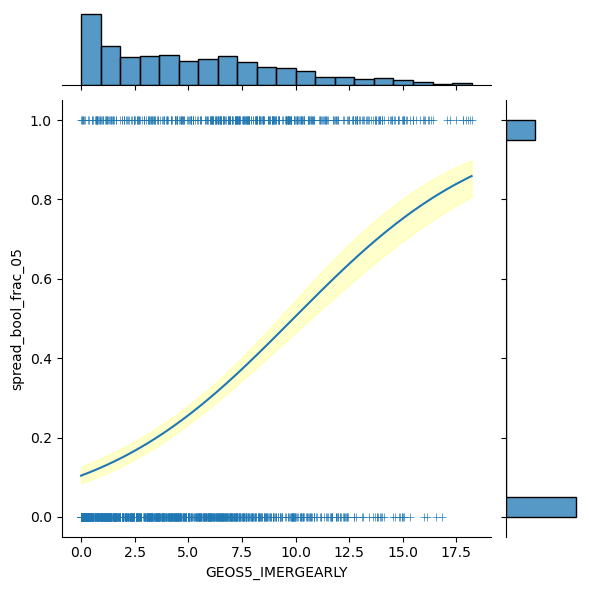

No growth detected, no values over nan in GEOS5_IMERGEARLY
['Model_mean'] had the best accuracy (0.7301694915254238). Other scores were: 
          0                 1
0  0.000000              Null
1  0.730169        Model_mean
2  0.689492  most_common_null
Mean model's accuracy is between 0.7471186440677966 and 0.7152542372881356


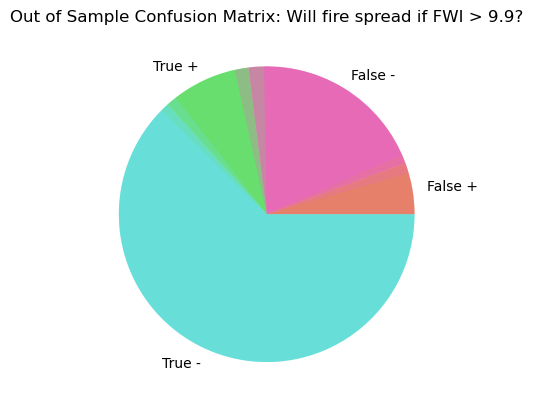

In [12]:

model = make_logit(fire_delta = fire, fire_test = fire_test, x= 'GEOS5_IMERGEARLY', y = "spread_bool_frac_05")






### 70% smallest fires -- 2km growth not different from Null. spread 0 -1  the model does beat out the null. (GEOS5_IMERGEEARLY)
## 90% smallest fires -- 2 km growth does just beat out the null. (GEOS5_IMERGEEARLY) 4km growth doesn't beat the null. 


### Testing in/out of sample sorted by space
### 2km spread -- mean safely beat the null 4km looses to the null. (GEOS5_IMERGEEARLY)

## Testing "life stage" of fire
## 2km spread -- mean beats null. null beats out mean. 6km null also beats out mean



## Fractional change tests
## fractional change > 0.1 was not significant (GEOS5_IMERGEEARLY)
## fractional change > 0.05 Was significant (GEOS5_IMERGEEARLY)



In [146]:
# Per fire logit distribution

# def make_logit_one_fire(df,  x= 'GEOS5_IMERGEARLY', y = "spread_bool_frac_05"):
#     fire_delta = df.copy()
#     #fire_delta = fire_delta[[x, y]].dropna()
#     fire_delta = fire_delta[[x, y]].drop_duplicates()
#     fire_delta = fire_delta[[x , y]].dropna()

#     keep_going = True
#     if(len(fire_delta[y].unique()) <= 1):
#         keep_going = False
#     if(len(fire_delta[x].unique()) <= 1):
#         keep_going = False

#     if keep_going:
        
#         formula = f"{y} ~ {x}"
    
        
#         pre_model = smf.logit(formula, data=fire_delta)

#         model = pre_model.fit()

#         # model_null = baseline_null_model(fire_delta, x = x, y = y)
    
#         # print(f"Model has AIC of {round(model.aic, 3)}, null model aic of {round(model_null.aic, 3)}") 

            
        
#         # sns.jointplot(data=fire_delta, x= x, y=y, marker="+",  dropna = True, marginal_kws = {"bins": 20}) #  marginal_kws = {"log_scale": True} 
#         #t.ax_marg_y.set_yscale("log")
#         max_of_max = round(max(fire_delta[x].max(), fire_delta[y].max()))
#         min_of_min = round(min(fire_delta[x].min(), fire_delta[y].min()))
#         fire_delta['fitted'] = model.fittedvalues
#         #fire_delta['residuals'] = model.resid_response
#         fire_delta = fire_delta.sort_values(by = x)
#         predictions = model.get_prediction(fire_delta) #df, transform = False
#         fire_delta['predicted'] = predictions.predicted
#         fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T
#         # plt.fill_between(fire_delta[x], fire_delta['conf_int_low'], fire_delta['conf_int_high'], alpha=0.2, color = "yellow")
#         # sns.lineplot(x=x, y='predicted', data=fire_delta, legend = False)
#         # plt.show()
        
#         thresh = 0.5
#         will_grow = fire_delta[fire_delta['predicted'] > thresh][x].min()
        
#         mean = calc_confusion_matrix_individual(fire_delta = fire_delta, fire_test = None, thresh = thresh, x = x, y = y, pred_column= "predicted")
#         #upper = calc_confusion_matrix_individual(fire_delta = fire_delta, fire_test = None, thresh = thresh, x = x, y = y, pred_column= "conf_int_high")
#         #lower = calc_confusion_matrix_individual(fire_delta = fire_delta, fire_test = None, thresh = thresh, x = x, y = y, pred_column= "conf_int_low")
#         #print(mean)
#         if(mean is not None):
    
#             ## Make null models
#             # predictions_null = model_null.get_prediction(fire_delta)
#             # fire_delta['predicted_null'] = predictions_null.predicted
        
            
#             #mean_null = calc_confusion_matrix(fire_delta = fire_delta, fire_test = None, thresh = thresh, x = x, y = y, pred_column= "predicted_null")
        
#             fire_delta.loc[:, 'most_common'] = fire_delta[y].mode().iloc[0]
#             fire_test.loc[:, 'most_common'] = fire_test[y].mode().iloc[0]
#             #return(fire_delta)
#             mean_common = common_confusion_matrix(fire_delta = fire_delta, fire_test = None, thresh = thresh, x = x, y = y, pred_column= "most_common")
#             #print(mean_common)
        
#            # percent_right_null = (mean_null[2] + mean_null[3]) / 1
#             percent_right = (mean[3] + mean[2]) / 1
#             #percent_right_upper = (upper[3] + upper[2]) / 1
#             #percent_right_lower = (lower[3] + lower[2]) / 1
#             percent_right_common = (mean_common[3] + mean_common[2]) / 1
        
#             # if(percent_right > any([percent_right_null, percent_right_common])):
#             #     print(f"Model accuracy ({percent_right}) better than null ({percent_right_null}), consistancy model ({percent_right_common}))")
#             #     if((percent_right_null > any([percent_right_upper, percent_right_lower])) or (percent_right_common > any([percent_right_upper, percent_right_lower]))):
#             #         print("But accuracy is within range of model error.")
#             # else:
#             scores = [ percent_right, percent_right_common]
#             score_names = [ "Model_mean", "most_common_null"]
#             scores_df = pd.DataFrame(zip(scores, score_names))
#             # print(f"{scores_df[scores_df.loc[:, 0] == scores_df.loc[:, 0].max()].loc[:, 1].values} had the best accuracy ({scores_df.loc[:, 0].max()}). Other scores were: ")
#             # print(scores_df)
        
#             #print(f"Mean model's accuracy is between {percent_right_upper} and {percent_right_lower}")
                
#             #return(scores_df)
                          
                
        
    
#     #rates = np.array(mean)
        
#         # mylabels = ["False +", "False -", "True +", "True -"]
#         # mycolors = ["#dd4626", "#dd2695", "#22d12c", "#22d1c9"]
        
    
#         # plt.pie(mean, labels = mylabels, wedgeprops={"alpha": 0.5}, colors = mycolors)
#         # plt.pie(upper, wedgeprops={"alpha": 0.2}, colors = mycolors)
#         # plt.pie(lower, wedgeprops={"alpha": 0.2}, colors = mycolors)
        
#         # plt.title(f"Out of Sample Confusion Matrix: Will fire spread if FWI > {round(will_grow, 2)}?")
#         # #plt.pie(y, )
#         # plt.show() 
        
#         ## Test against some null models    
#         #print(f"Model has AIC of {model.aic}, null model aic of {model_null.aic}") 
    
#         ### comparing accuracy
#             if(scores_df.iloc[0][0] > scores_df.iloc[1][0]):
#                 df.loc[:, f"{x}_thresh_{y}"] = will_grow
#             else:
#                 df.loc[:, f"{x}_thresh_{y}"] = None
#         else:
#             df.loc[:, f"{x}_thresh_{y}"] = None
#     else:
#         df.loc[:, f"{x}_thresh_{y}"] = None
  
    
#     return(df)


#y = "spread_bool_200"
y = "spread_bool_frac_05"
def make_logit_one_fire(df, x='GEOS5_IMERGEARLY', y= y ):
    fire_delta = df[[x, y]].drop_duplicates().dropna()

    if len(fire_delta[y].unique()) <= 1 or len(fire_delta[x].unique()) <= 1:
        df[f"{x}_thresh_{y}"] = None
        return df

    try:
        formula = f"{y} ~ {x}"
        model = smf.logit(formula, data=fire_delta).fit()
    except Exception as e:
        print(f"Error fitting the model: {e}")
        df[f"{x}_thresh_{y}"] = None
        return df

    fire_delta['fitted'] = model.fittedvalues
    predictions = model.get_prediction(fire_delta)
    fire_delta['predicted'] = predictions.predicted
    fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T

    thresh = 0.5
    will_grow = fire_delta[fire_delta['predicted'] > thresh][x].min()

    mean = calc_confusion_matrix_individual(fire_delta=fire_delta, fire_test=None, thresh=thresh, x=x, y=y, pred_column="predicted")

    if mean is None:
        df[f"{x}_thresh_{y}"] = None
        return df

    fire_delta['most_common'] = fire_delta[y].mode().iloc[0]
    mean_common = common_confusion_matrix(fire_delta=fire_delta, fire_test=None, thresh=thresh, x=x, y=y, pred_column="most_common")

    percent_right = (mean[3] + mean[2]) / 1
    percent_right_common = (mean_common[3] + mean_common[2]) / 1

    scores = [percent_right, percent_right_common]
    score_names = ["Model_mean", "most_common_null"]
    scores_df = pd.DataFrame(list(zip(scores, score_names)), columns=['Score', 'Model'])

    df[f"{x}_thresh_{y}"] = will_grow if scores_df.iloc[0]['Score'] > scores_df.iloc[1]['Score'] else None

    return df


In [147]:
big_fr = fire3[fire3.fireID == '226'] ## Big fire
mid_fr2 = fire3[fire3.fireID == '3718'] ## mid fire 80 -- wait we didn;t catch any change here. 
mid_fr = fire3[fire3.fireID == '3423']

tmp = make_logit_one_fire(mid_fr2, x= 'GEOS5_IMERGEARLY', y = y)

/srv/conda/envs/notebook/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [148]:
fire_df = fire3.copy()


long_fires = fire_df.groupby("fireID").duration.max().reset_index()
long_fires = long_fires[long_fires.duration > 6].fireID

fire_df = fire_df[fire_df.fireID.isin(long_fires)]
fire_df = fire_df.groupby("fireID").apply(make_logit_one_fire).reset_index(drop = True)

Optimization terminated successfully.
         Current function value: 0.489669
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.280624
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.454565
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.259285
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.239609
         Iterations 7
No growth detected, no values over nan in GEOS5_IMERGEARLY
Optimization terminated successfully.
         Current function value: 0.266719
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.423243
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.461798
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.263263
         Iterations 8
Optimization terminated

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
/srv/conda/envs/notebook/lib

Optimization terminated successfully.
         Current function value: 0.624718
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.239878
         Iterations 7
No growth detected, no values over nan in GEOS5_IMERGEARLY
Optimization terminated successfully.
         Current function value: 0.412056
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.496100
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.597906
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.274115
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.573558
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.459109
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.540936
         Iterations 5
Optimization terminated

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified


Optimization terminated successfully.
         Current function value: 0.348714
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.451035
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.451323
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.459914
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.625355
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.561506
         Iterations 5
No growth detected, no values over nan in GEOS5_IMERGEARLY
Optimization terminated successfully.
         Current function value: 0.261234
         Iterations 7
         Current function value: 0.000000
         Iterations: 35
Optimization terminated successfully.
         Current function value: 0.445200
         Iterations 6
No growth detected, no values over nan in GEOS5_IMERGEARLY


/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp


Optimization terminated successfully.
         Current function value: 0.460391
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.338495
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.503319
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.515700
         Iterations 6
No growth detected, no values over nan in GEOS5_IMERGEARLY
Optimization terminated successfully.
         Current function value: 0.466495
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.440635
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.648678
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.520333
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.507200
         Iterations 6
No growth detected, no 

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp


Optimization terminated successfully.
         Current function value: 0.286164
         Iterations 6
No growth detected, no values over nan in GEOS5_IMERGEARLY
Optimization terminated successfully.
         Current function value: 0.381043
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.292529
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.595657
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.499087
         Iterations 5
No growth detected, no values over nan in GEOS5_IMERGEARLY
Optimization terminated successfully.
         Current function value: 0.593764
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.451955
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.472056
         Iterations 6
Optimization terminated successfully.
         Current function va

/tmp/ipykernel_547/1608427087.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/tmp/ipykernel_547/1608427087.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [149]:
y_col_name = f'GEOS5_IMERGEARLY_thresh_{y}'


pct_fire_sig = len(fire_df[~fire_df[y_col_name].isna()].fireID.unique()) / len(fire_df.fireID.unique())

print(f'Percent of fires that logit that found a significant spread threoshold for {y} {pct_fire_sig }')



# pct_fire_sig = len(fire_df[~fire_df.GEOS5_IMERGEARLY_thresh_spread_bool_200.isna()].fireID.unique()) / len(fire_df.fireID.unique())

# print(f'Percent of fires that logit that found a significant spread threoshold for spread_bool_200 {pct_fire_sig }')

Percent of fires that logit that found a significant spread threoshold for spread_bool_frac_05 0.6146788990825688


Text(0.5, 1.0, ' N = 67 fires, 61.0% of total fires. Logit models fit against GEOS5 + IMERGE')

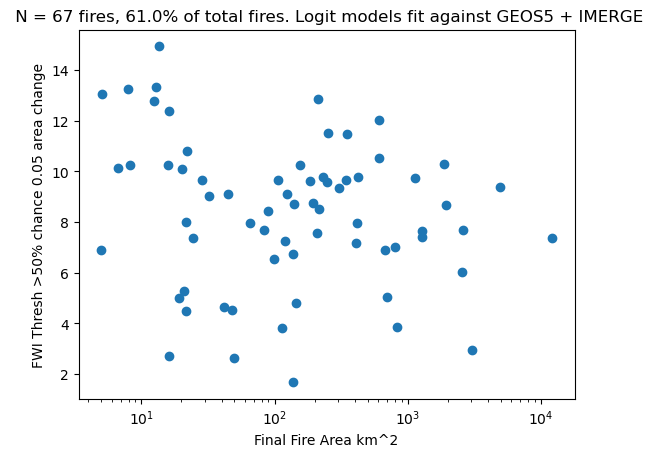

In [150]:
plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max())
plt.xlabel("Final Fire Area km^2")
#plt.ylabel(f"FWI Threshold for >50% chance of {y}")
plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
plt.xscale("log")
plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. Logit models fit against GEOS5 + IMERGE")

In [151]:
# plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max())
# plt.xlabel("Final Fire Area km^2")
# #plt.ylabel(f"FWI Threshold for >50% chance of {y}")
# plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
# plt.xscale("log")
# plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. Logit models fit against GEOS5 + IMERGE")



### color by lat, supression, time of ignition, and fuels if I can swing it. 

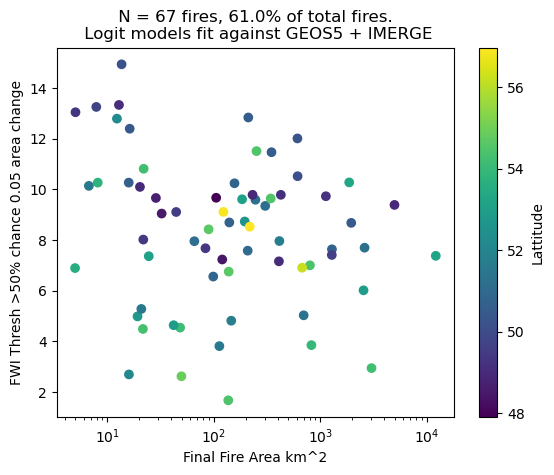

In [152]:
plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max(), c = fire_projected[fire_projected.fireID.isin(fire_df.fireID.unique())].groupby('fireID')["Lat"].max())
plt.xlabel("Final Fire Area km^2")
#plt.ylabel(f"FWI Threshold for >50% chance of {y}")
plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
plt.xscale("log")
plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. \n Logit models fit against GEOS5 + IMERGE")
plt.colorbar(label = "Lattitude")

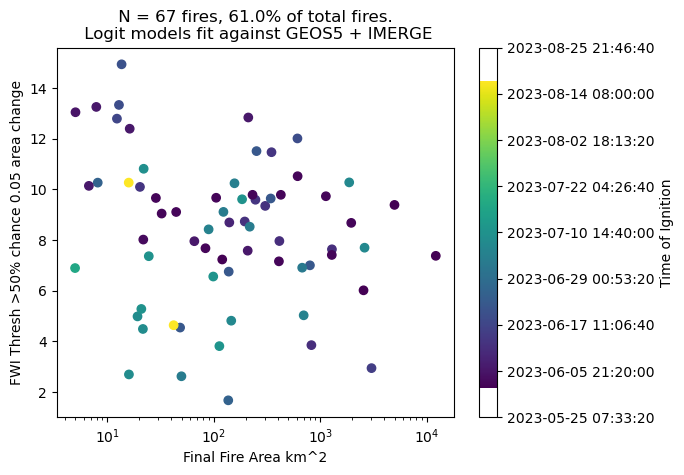

In [153]:
from matplotlib import dates
import datetime
from datetime import datetime

plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max(), c = fire_df[fire_df.is_ig == True].t.astype("datetime64[ns]"))#.astype("int") )
plt.xlabel("Final Fire Area km^2")
#plt.legend()
#plt.ylabel(f"FWI Threshold for >50% chance of {y}")
plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
plt.xscale("log")
plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. \n Logit models fit against GEOS5 + IMERGE")
cbar = plt.colorbar(label = "Time of Ignition")

ticks = cbar.get_ticks()

# Convert integer ticks to datetime objects
datetimes = [datetime.fromtimestamp(t // 10**9) for t in ticks]

# Format the colorbar ticks as HH:MM:SS
cbar.ax.yaxis.set_major_formatter(dates.DateFormatter('%m-%d'))

# Update the tick labels with the formatted datetimes
cbar.set_ticks(ticks)
cbar.set_ticklabels(datetimes)


# Update the tick labels with the formatted datetimes
